# GStatSim Parallel Implementation Demo
This notebook provides a demo of how to use each parallelized interpolation function. Note that the code used to run these functions can be found in the *parallel.py* file. 

In [1]:
import sys
sys.path.append("../")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LightSource
from sklearn.preprocessing import QuantileTransformer
import skgstat as skg
from skgstat import models
import gstatsim as gs
import parallel
from sklearn.cluster import KMeans

## Prepare Data
The code cells below are used to prepare the data to be used in the various interpolation functions.

In [2]:
df_bed = pd.read_csv('data/greenland_test_data.csv')

# remove erroneously high values due to bad bed picks
df_bed = df_bed[df_bed["Bed"] <= 700]  

In [3]:
# set number of processes you would like to spawn for parallel process
num_proc = 10

In [4]:
# grid data to 100 m resolution and remove coordinates with NaNs
res = 1000
df_grid, grid_matrix, rows, cols = gs.Gridding.grid_data(df_bed, 'X', 'Y', 'Bed', res)
df_grid = df_grid[df_grid["Z"].isnull() == False]
df_grid = df_grid.rename(columns = {"Z": "Bed"})

# normal score transformation
data = df_grid['Bed'].values.reshape(-1,1)
nst_trans = QuantileTransformer(n_quantiles=500, output_distribution="normal").fit(data)
df_grid['Nbed'] = nst_trans.transform(data) 

coords = df_grid[['X','Y']].values
values = df_grid['Nbed']

k = 50         # number of neighboring data points used to estimate a given point
rad = 50000     # 50 km search radius

In [5]:
# define coordinate grid
xmin = np.min(df_grid['X']); xmax = np.max(df_grid['X'])     # min and max x values
ymin = np.min(df_grid['Y']); ymax = np.max(df_grid['Y'])     # min and max y values

# initialize grid
Pred_grid_xy = gs.Gridding.prediction_grid(xmin, xmax, ymin, ymax, res)

In [6]:
# compute experimental (isotropic) variogram

maxlag = 50000             # maximum range distance
n_lags = 70                # num of bins

V1 = skg.Variogram(coords, values, bin_func='even', n_lags=n_lags, 
                   maxlag=maxlag, normalize=False)

# use exponential variogram model
V1.model = 'exponential'
V1.parameters

# set variogram parameters
azimuth = 0
nugget = V1.parameters[2]

# the major and minor ranges are the same in this example because it is isotropic
major_range = V1.parameters[0]
minor_range = V1.parameters[0]
sill = V1.parameters[1]
vtype = 'Exponential'

# save variogram parameters as a list
vario = [azimuth, nugget, major_range, minor_range, sill, vtype]

## Simple and Ordinary Kriging

### Simple Kriging

In [7]:
%time est_SK, var_SK = parallel.skrige(Pred_grid_xy, df_grid, 'X', 'Y', 'Nbed', k, vario, rad, num_proc)

CPU times: user 2.4 s, sys: 159 ms, total: 2.55 s
Wall time: 5.79 s


In [8]:
# reverse normal score transformation

var_SK[var_SK < 0] = 0      # make sure variances are non-negative
std_SK = np.sqrt(var_SK)    # convert to standard deviation before back transforming

# reshape
est = est_SK.reshape(-1,1)
std = std_SK.reshape(-1,1)

# back transformation
spred_trans = nst_trans.inverse_transform(est)
sstd_trans = nst_trans.inverse_transform(std)
sstd_trans = sstd_trans - np.min(sstd_trans)

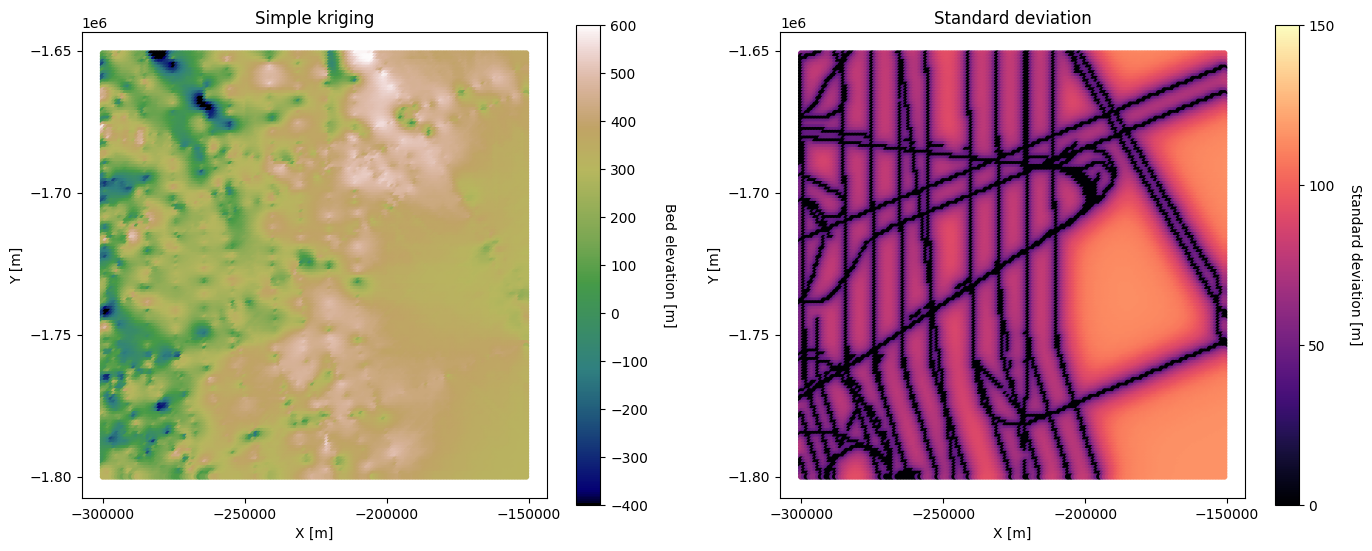

In [9]:
# plot simple kriging and standard deviation
fig = plt.figure()
plt.subplot(121) 
im = plt.scatter(Pred_grid_xy[:,0],Pred_grid_xy[:,1], c = spred_trans, vmin = -400, vmax = 600, marker=".", s = 50,
                cmap = 'gist_earth')       # scatter plot for location map
plt.title('Simple kriging')                                    # add plot title
plt.xlabel('X [m]'); plt.ylabel('Y [m]')                          # set axis labels
plt.locator_params(nbins=5)# set axis labels
cbar = plt.colorbar(im, orientation="vertical", ticks=np.linspace(-400, 600, 11)) # add vertical color bar
cbar.set_label("Bed elevation [m]", rotation=270, labelpad=20)      # add labels to the color bar
plt.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0) # adjust the plot size
plt.axis('scaled')

plt.subplot(122) 
im = plt.scatter(Pred_grid_xy[:,0],Pred_grid_xy[:,1], c = sstd_trans, vmin = 0, vmax = 150, marker=".", s = 50,
                cmap = 'magma')       # scatter plot for location map
plt.title('Standard deviation')                                    # add plot title
plt.xlabel('X [m]'); plt.ylabel('Y [m]')                          # set axis labels
plt.locator_params(nbins=5)# set axis labels
cbar = plt.colorbar(im, orientation="vertical", ticks=np.linspace(0, 250, 6)) # add vertical color bar
cbar.set_label("Standard deviation [m]", rotation=270, labelpad=20)      # add labels to the color bar
plt.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0) # adjust the plot size
plt.axis('scaled')

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=1.0, wspace=0.2, hspace=0.3)
plt.show()

### Ordinary Kriging

In [10]:
%time est_OK, var_OK = parallel.okrige(Pred_grid_xy, df_grid, 'X', 'Y', 'Nbed', k, vario, rad, num_proc)

CPU times: user 2.16 s, sys: 171 ms, total: 2.34 s
Wall time: 6.03 s


In [11]:
# reverse normal score transformation
var_OK[var_OK < 0] = 0; # make sure variances are non-negative
std_OK = np.sqrt(var_OK) # convert to standard deviation (this should be done before back transforming!!!)

# reshape
est = est_OK.reshape(-1,1)
std = std_OK.reshape(-1,1)

# back transformation
pred_trans = nst_trans.inverse_transform(est)
std_trans = nst_trans.inverse_transform(std)
std_trans = std_trans - np.min(std_trans)

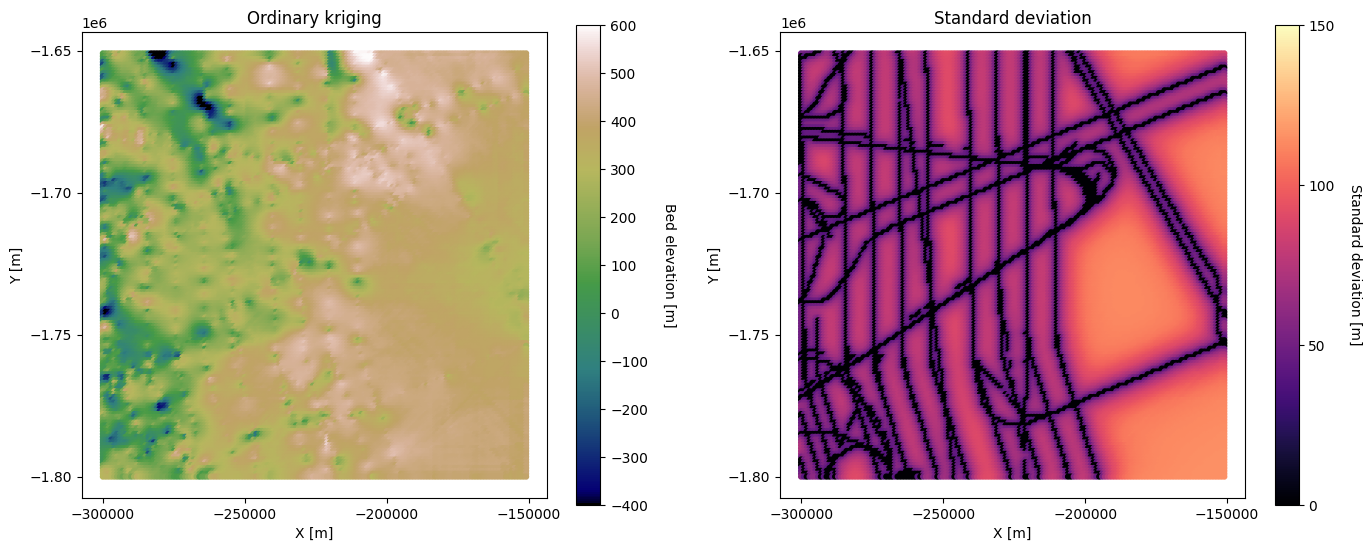

In [12]:
# plot ordinary kriging and stnadard deviation
fig = plt.figure()
plt.subplot(121) 
im = plt.scatter(Pred_grid_xy[:,0],Pred_grid_xy[:,1], c = pred_trans, vmin = -400, vmax = 600, marker=".", s = 50,
                cmap = 'gist_earth')       # scatter plot for location map
plt.title('Ordinary kriging')                                    # add plot title
plt.xlabel('X [m]'); plt.ylabel('Y [m]')                          # set axis labels
plt.locator_params(nbins=5)# set axis labels
cbar = plt.colorbar(im, orientation="vertical", ticks=np.linspace(-400, 600, 11)) # add vertical color bar
cbar.set_label("Bed elevation [m]", rotation=270, labelpad=20)      # add labels to the color bar
plt.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0) # adjust the plot size
plt.axis('scaled')

plt.subplot(122) 
im = plt.scatter(Pred_grid_xy[:,0],Pred_grid_xy[:,1], c = std_trans, vmin = 0, vmax = 150, marker=".", s = 50,
                cmap = 'magma')       # scatter plot for location map
plt.title('Standard deviation')                                    # add plot title
plt.xlabel('X [m]'); plt.ylabel('Y [m]')                          # set axis labels
plt.locator_params(nbins=5)# set axis labels
cbar = plt.colorbar(im, orientation="vertical", ticks=np.linspace(0, 250, 6)) # add vertical color bar
cbar.set_label("Standard deviation [m]", rotation=270, labelpad=20)      # add labels to the color bar
plt.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0) # adjust the plot size
plt.axis('scaled')

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=1.0, wspace=0.2, hspace=0.3)
plt.show()

## SGS with Simple and Ordinary Kriging

### SGS w/ Simple Kriging

In [13]:
%time sgs_skrig = parallel.skrige_sgs(Pred_grid_xy, df_grid, 'X', 'Y', 'Nbed', k, vario, rad, num_proc)

CPU times: user 3.99 s, sys: 316 ms, total: 4.3 s
Wall time: 14.2 s


In [14]:
# reverse normal score transformation
sim1 = sgs_skrig.reshape(-1,1)
sim_trans = nst_trans.inverse_transform(sim1)

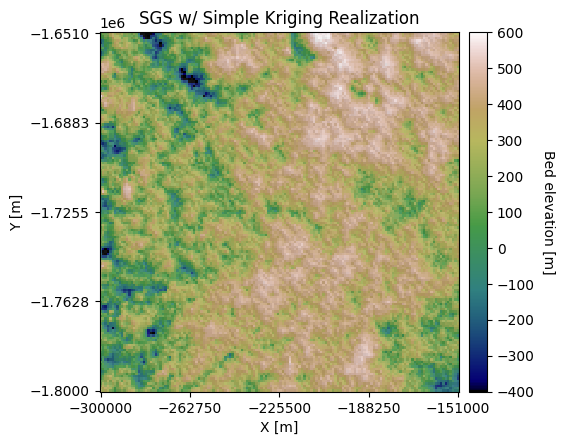

In [15]:
vmin = -400; vmax = 600
x_mat = Pred_grid_xy[:,0].reshape((rows, cols))
y_mat = Pred_grid_xy[:,1].reshape((rows, cols))
mat = sim_trans.reshape((rows, cols))
xmin = Pred_grid_xy[:,0].min(); xmax = Pred_grid_xy[:,0].max()
ymin = Pred_grid_xy[:,1].min(); ymax = Pred_grid_xy[:,1].max()
    
cmap=plt.get_cmap('gist_earth')
fig, ax = plt.subplots(1, figsize=(5,5))
im = ax.pcolormesh(x_mat, y_mat, mat, vmin=vmin, vmax=vmax, cmap=cmap)
    
# Shade from the northeast, with the sun 45 degrees from horizontal
ls = LightSource(azdeg=45, altdeg=45)
        
# leaving the dx and dy as 1 means a vertical exageration equal to dx/dy
hillshade = ls.hillshade(mat, vert_exag=1, dx=1, dy=1, fraction=1.0)
plt.pcolormesh(x_mat, y_mat, hillshade, cmap='gray', alpha=0.1)
plt.title('SGS w/ Simple Kriging Realization')
plt.xlabel('X [m]'); plt.ylabel('Y [m]')
plt.xticks(np.linspace(xmin, xmax, 5))
plt.yticks(np.linspace(ymin, ymax, 5))

# make colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = plt.colorbar(im, ticks=np.linspace(-400, 600, 11), cax=cax)
cbar.set_label("Bed elevation [m]", rotation=270, labelpad=15)
ax.axis('scaled')
plt.show()

### SGS w/ Ordinary Kriging

In [16]:
%time sgs_okrig = parallel.okrige_sgs(Pred_grid_xy, df_grid, 'X', 'Y', 'Nbed', k, vario, rad, num_proc)

CPU times: user 3.87 s, sys: 383 ms, total: 4.25 s
Wall time: 14.7 s


In [17]:
# reverse normal score transformation
sim2 = sgs_okrig.reshape(-1,1)
sim2_trans = nst_trans.inverse_transform(sim2)

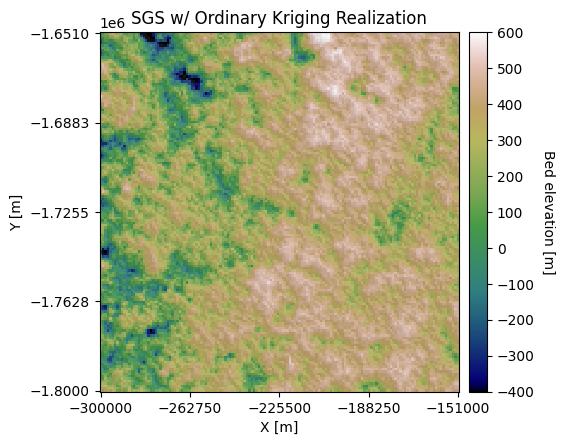

In [18]:
vmin = -400; vmax = 600
x_mat = Pred_grid_xy[:,0].reshape((rows, cols))
y_mat = Pred_grid_xy[:,1].reshape((rows, cols))
mat = sim2_trans.reshape((rows, cols))
xmin = Pred_grid_xy[:,0].min(); xmax = Pred_grid_xy[:,0].max()
ymin = Pred_grid_xy[:,1].min(); ymax = Pred_grid_xy[:,1].max()
    
cmap=plt.get_cmap('gist_earth')
fig, ax = plt.subplots(1, figsize=(5,5))
im = ax.pcolormesh(x_mat, y_mat, mat, vmin=vmin, vmax=vmax, cmap=cmap)
    
# Shade from the northeast, with the sun 45 degrees from horizontal
ls = LightSource(azdeg=45, altdeg=45)
        
# leaving the dx and dy as 1 means a vertical exageration equal to dx/dy
hillshade = ls.hillshade(mat, vert_exag=1, dx=1, dy=1, fraction=1.0)
plt.pcolormesh(x_mat, y_mat, hillshade, cmap='gray', alpha=0.1)
plt.title('SGS w/ Ordinary Kriging Realization')
plt.xlabel('X [m]'); plt.ylabel('Y [m]')
plt.xticks(np.linspace(xmin, xmax, 5))
plt.yticks(np.linspace(ymin, ymax, 5))

# make colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = plt.colorbar(im, ticks=np.linspace(-400, 600, 11), cax=cax)
cbar.set_label("Bed elevation [m]", rotation=270, labelpad=15)
ax.axis('scaled')
plt.show()

## Cluster SGS
The immediate code cell below is an additional data preperation step to partition the conditioning data and compute the unique variogram parameters for each partition.

In [19]:
# K means clustering
n_clusters = 3
kmeans = KMeans(n_clusters = n_clusters, random_state = 0, n_init = 10).fit(df_grid[['X','Y','Nbed']])
df_grid['K'] = kmeans.labels_  # make column in dataframe with cluster name

# experimental variogram parameters
maxlag = 50000
n_lags = 70 #num of bins

# cluster 0 variogram
df0 = df_grid[df_grid['K'] == 0]
coords0 = df0[['X','Y']].values
values0 = df0['Nbed']
V0 = skg.Variogram(coords0, values0, bin_func = "even", n_lags = n_lags, 
                   maxlag = maxlag, normalize=False)


# cluster 1 variogram
df1 = df_grid[df_grid['K'] == 1]
coords1 = df1[['X','Y']].values
values1 = df1['Nbed']
V1 = skg.Variogram(coords1, values1, bin_func = "even", n_lags = n_lags, 
                   maxlag = maxlag, normalize=False)


# cluster 2 variogram
df2 = df_grid[df_grid['K'] == 2]
coords2 = df2[['X','Y']].values
values2 = df2['Nbed']
V2 = skg.Variogram(coords2, values2, bin_func = "even", n_lag = n_lags, 
                   maxlag = maxlag, normalize=False) 

range0 = V0.parameters[0]; sill0 = V0.parameters[1]
range1 = V1.parameters[0]; sill1 = V1.parameters[1]
range2 = V2.parameters[0]; sill2 = V2.parameters[1]

# make a list with variogram parameters
azimuth = 0

# nugget effect
nug = 0 

# variogram model
vtype = 'Exponential'

# define variograms for each cluster
# Azimuth, nugget, major range, minor range, sill
gam0 = [azimuth, nug, range0, range0, sill0, vtype]
gam1 = [azimuth, nug, range1, range1, sill1, vtype]
gam2 = [azimuth, nug, range2, range2, sill2, vtype]

# store variogram parameters
df_gamma = pd.DataFrame({'Variogram': [gam0, gam1, gam2]})

In [20]:
%time cluster_sgs = parallel.cluster_sgs(Pred_grid_xy, df_grid, 'X', 'Y', 'Nbed', 'K', k, df_gamma, rad, num_proc)

CPU times: user 5.34 s, sys: 464 ms, total: 5.81 s
Wall time: 15.6 s


In [21]:
# reverse normal score transformation
sim3 = cluster_sgs.reshape(-1,1)
sim3_trans = nst_trans.inverse_transform(sim3)

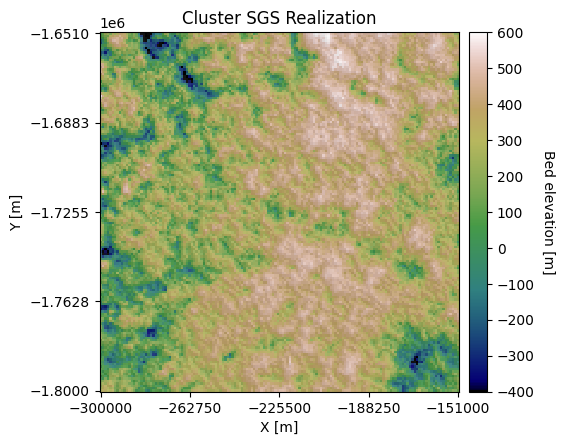

In [22]:
vmin = -400; vmax = 600
x_mat = Pred_grid_xy[:,0].reshape((rows, cols))
y_mat = Pred_grid_xy[:,1].reshape((rows, cols))
mat = sim3_trans.reshape((rows, cols))
xmin = Pred_grid_xy[:,0].min(); xmax = Pred_grid_xy[:,0].max()
ymin = Pred_grid_xy[:,1].min(); ymax = Pred_grid_xy[:,1].max()
    
cmap=plt.get_cmap('gist_earth')
fig, ax = plt.subplots(1, figsize=(5,5))
im = ax.pcolormesh(x_mat, y_mat, mat, vmin=vmin, vmax=vmax, cmap=cmap)
    
# Shade from the northeast, with the sun 45 degrees from horizontal
ls = LightSource(azdeg=45, altdeg=45)
        
# leaving the dx and dy as 1 means a vertical exageration equal to dx/dy
hillshade = ls.hillshade(mat, vert_exag=1, dx=1, dy=1, fraction=1.0)
plt.pcolormesh(x_mat, y_mat, hillshade, cmap='gray', alpha=0.1)
plt.title('Cluster SGS Realization')
plt.xlabel('X [m]'); plt.ylabel('Y [m]')
plt.xticks(np.linspace(xmin, xmax, 5))
plt.yticks(np.linspace(ymin, ymax, 5))

# make colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = plt.colorbar(im, ticks=np.linspace(-400, 600, 11), cax=cax)
cbar.set_label("Bed elevation [m]", rotation=270, labelpad=15)
ax.axis('scaled')
plt.show()

## CO-Kriging and CO-SGS with Markov Model 1

### Prepare secondary data

In [23]:
# download data
df_surface = pd.read_csv('data/greenland_surface_data.csv')

# grid secondary data
res = 200
df_surface_grid, surface_grid_matrix, rows_surface, cols_surface = gs.Gridding.grid_data(df_surface, 'X', 'Y', 'Surface', res) 
df_surface_grid = df_surface_grid.rename(columns = {"Z": "Surface"}) # rename column for consistency

# normal score transformation
data_surf = df_surface_grid['Surface'].values.reshape(-1,1)
nst_trans_surf = QuantileTransformer(n_quantiles=500, output_distribution="normal").fit(data_surf)
df_surface_grid['Nsurf'] = nst_trans_surf.transform(data_surf) 

# find co-located secondary data
df_colocated = gs.NearestNeighbor.find_colocated(df_grid, 'X', 'Y', 'Nbed', df_surface_grid, 'X', 'Y', 'Nsurf')

# compute correlation coefficient
rho12 = np.corrcoef(df_grid['Nbed'],df_colocated['colocated'])
corrcoef = rho12[0,1]
print('Correlation coefficient between bed and surface: ' + str(corrcoef))

Correlation coefficient between bed and surface: 0.5645032956716013


### CO-Kriging

In [24]:
%time est_cokrige, var_cokrige = parallel.cokrige_mm1(Pred_grid_xy, df_grid, 'X', 'Y', 'Nbed', df_surface_grid, 'X', 'Y', 'Nsurf', k, vario, rad, corrcoef, num_proc)

CPU times: user 4.1 s, sys: 504 ms, total: 4.6 s
Wall time: 1min 36s


In [25]:
# reverse normal score transformation
var_cokrige[var_cokrige < 0] = 0; # make sure variances are non-negative
std_cokrige = np.sqrt(var_cokrige) # convert to standard deviation (this should be done before back transforming!!!)

# reshape
est = est_cokrige.reshape(-1,1)
std = std_cokrige.reshape(-1,1)

# back transformation
cokrige_pred_trans = nst_trans.inverse_transform(est)
cokrige_std_trans = nst_trans.inverse_transform(std)
cokrige_std_trans = cokrige_std_trans - np.min(cokrige_std_trans)

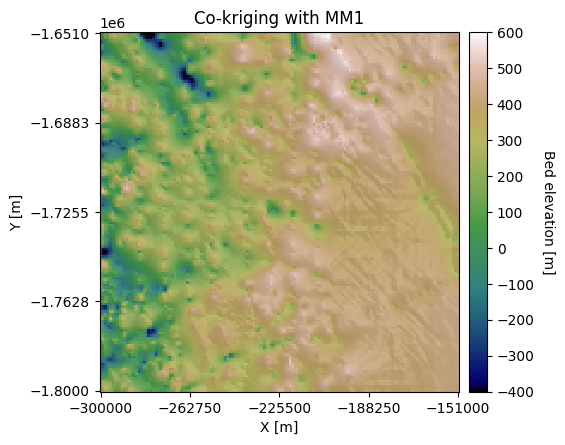

In [26]:
# make hillshade for visualizing
vmin = -400; vmax = 600
x_mat = Pred_grid_xy[:,0].reshape((rows, cols))
y_mat = Pred_grid_xy[:,1].reshape((rows, cols))
mat = cokrige_pred_trans.reshape((rows, cols))
xmin = Pred_grid_xy[:,0].min(); xmax = Pred_grid_xy[:,0].max()
ymin = Pred_grid_xy[:,1].min(); ymax = Pred_grid_xy[:,1].max()
    
cmap=plt.get_cmap('gist_earth')
fig, ax = plt.subplots(1, figsize=(5,5))
im = ax.pcolormesh(x_mat, y_mat, mat, vmin=vmin, vmax=vmax, cmap=cmap)
    
# Shade from the northeast, with the sun 45 degrees from horizontal
ls = LightSource(azdeg=45, altdeg=45)
        
# leaving the dx and dy as 1 means a vertical exageration equal to dx/dy
hillshade = ls.hillshade(mat, vert_exag=1, dx=1, dy=1, fraction=1.0)
plt.pcolormesh(x_mat, y_mat, hillshade, cmap='gray', alpha=0.1)
plt.title('Co-kriging with MM1')
plt.xlabel('X [m]'); plt.ylabel('Y [m]')
plt.xticks(np.linspace(xmin, xmax, 5))
plt.yticks(np.linspace(ymin, ymax, 5))

# make colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = plt.colorbar(im, ticks=np.linspace(-400, 600, 11), cax=cax)
cbar.set_label("Bed elevation [m]", rotation=270, labelpad=15)
ax.axis('scaled')
plt.show()

### CO-SGS 

In [27]:
%time cosim = parallel.cosim_mm1(Pred_grid_xy, df_grid, 'X', 'Y', 'Nbed', df_surface_grid, 'X', 'Y', 'Nsurf', k, vario, rad, corrcoef, num_proc)

CPU times: user 5.37 s, sys: 598 ms, total: 5.96 s
Wall time: 1min 36s


In [28]:
# reverse normal score transformation
sgs_cosim = cosim.reshape(-1,1)
cosim_trans = nst_trans.inverse_transform(sgs_cosim)

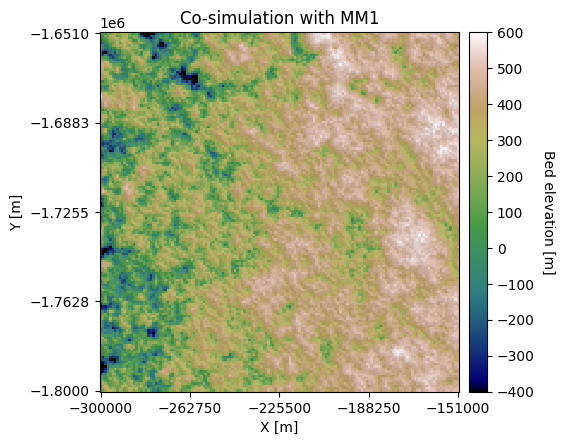

In [29]:
# make hillshade for visualizing
x_mat = Pred_grid_xy[:,0].reshape((rows, cols))
y_mat = Pred_grid_xy[:,1].reshape((rows, cols))
xmin = Pred_grid_xy[:,0].min(); xmax = Pred_grid_xy[:,0].max()
ymin = Pred_grid_xy[:,1].min(); ymax = Pred_grid_xy[:,1].max()

mat = cosim_trans.reshape((rows, cols))
vmin = -400; vmax = 600    
cmap=plt.get_cmap('gist_earth')
fig, ax = plt.subplots(1, figsize=(5,5))
im = ax.pcolormesh(x_mat, y_mat, mat, vmin=vmin, vmax=vmax, cmap=cmap)
    
# Shade from the northeast, with the sun 45 degrees from horizontal
ls = LightSource(azdeg=45, altdeg=45)
        
# leaving the dx and dy as 1 means a vertical exageration equal to dx/dy
hillshade = ls.hillshade(mat, vert_exag=1, dx=1, dy=1, fraction=1.0)
plt.pcolormesh(x_mat, y_mat, hillshade, cmap='gray', alpha=0.1)
plt.title('Co-simulation with MM1')
plt.xlabel('X [m]'); plt.ylabel('Y [m]')
plt.xticks(np.linspace(xmin, xmax, 5))
plt.yticks(np.linspace(ymin, ymax, 5))

# make colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = plt.colorbar(im, ticks=np.linspace(-400, 600, 11), cax=cax)
cbar.set_label("Bed elevation [m]", rotation=270, labelpad=15)
ax.axis('scaled')
plt.show()